<a href="https://colab.research.google.com/github/claudiolozea/Estatistica-e-Probabilidade-Aplicada-a-Astronomia/blob/main/Trabalho_fundamentos_estat%C3%ADtisca_R.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Etapa 1: Definição de Variáveis e Simulação dos Dados

Nesta primeira etapa, vamos simular os dados de brilho estelar (magnitude aparente) captados pelo telescópio. Para construir nossa base de dados teórica, definimos as seguintes variáveis principais:

*   **População (n):** 1.000 observações.
*   **Valor Central:** 15.5.
*   **Desvio Padrão ($\sigma$):** 0.8.

**Por que a Distribuição Normal?**
Na estatística inferencial, quando o tamanho da nossa amostra ou população é **maior que 30** e possuímos um **desvio padrão conhecido** , assumimos o uso da **Distribuição Normal** (Gaussiana) para modelar as probabilidades. A medição do brilho de astros afetada por ruídos naturais costuma seguir exatamente esse padrão de curva.

Para garantir que a nossa análise estatística possa ser auditada pelos professores, usamos a função `set.seed(42)` antes da geração dos dados. Isso fixa uma "semente" matemática, garantindo a reprodutibilidade dos mesmos números aleatórios toda vez que a função `rnorm()` for executada.


In [ ]:
# Configuração do ambiente e semente para reprodutibilidade
set.seed(42)

# 1. Simulação
brilho_estelar <- rnorm(n = 1000, mean = 15.5, sd = 0.8)

### Etapa 2: Análise Descritiva e Visualização

Nesta etapa, utilizamos a Estatística Descritiva para explorar o comportamento da amostra gerada. A principal ferramenta gráfica escolhida é o **Histograma**, que exibe a distribuição de frequências agrupadas das magnitudes de brilho captadas.

Para validar visualmente se a nossa amostra segue o comportamento teórico esperado para a estrela, sobrepomos ao histograma a **curva de densidade teórica da Distribuição Normal**

Warning message:
“The dot-dot notation (`..density..`) was deprecated in ggplot2 3.4.0.
ℹ Please use `after_stat(density)` instead.”


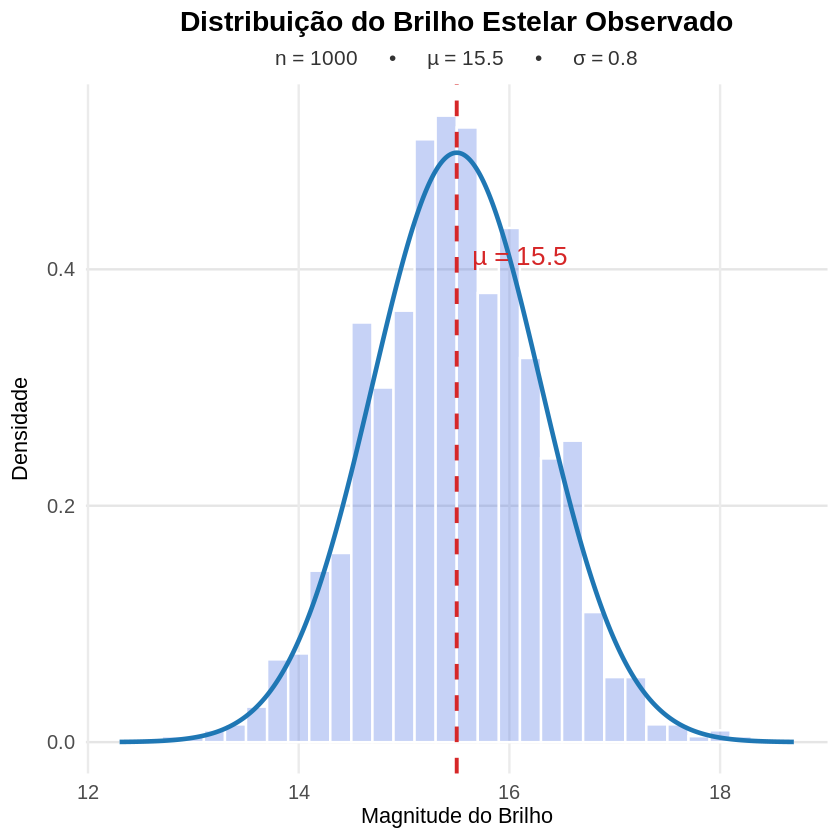

In [ ]:
library(ggplot2)

# Criando o dataframe com os dados simulados
df <- data.frame(brilho = brilho_estelar)

# Parâmetros teóricos da estrela
mu    <- 15.5      # média populacional esperada
sigma <- 0.8       # desvio padrão populacional (ruído)
n     <- 1000      # tamanho da amostra

# Gerar dados para a curva de densidade (espalhada pelo Desvio Padrão)
x_vals <- seq(mu - 4*sigma, mu + 4*sigma, length.out = 500)
dens   <- dnorm(x_vals, mean = mu, sd = sigma)

# Gráfico com ggplot2
ggplot() +

  # Histograma das medições (área proporcional à densidade)
  geom_histogram(data = df, aes(x = brilho, y = ..density..),
                 binwidth = 0.2, fill = "royalblue", color = "white", alpha = 0.3) +

  # Curva normal teórica
  geom_line(aes(x = x_vals, y = dens),
            color = "#1f77b4", linewidth = 1.3) +

  # Linha vertical na média populacional
  geom_vline(xintercept = mu,
             color = "#d62728", linetype = "dashed", linewidth = 1.1) +

  # Anotação da Média Central (Ajustada para o lado)
  annotate("text", x = mu + 0.6, y = 0.82 * max(dens),
           label = expression(mu == 15.5),
           color = "#d62728", size = 5.5, fontface = "bold") +

  # Rótulos e títulos
  labs(title = "Distribuição do Brilho Estelar Observado",
       subtitle = bquote(n == .(n) ~ "   •   " ~ mu == .(mu) ~ "   •   " ~ sigma == .(sigma)),
       x = "Magnitude do Brilho",
       y = "Densidade") +

  # Tema limpo e elegante (mantido do original)
  theme_minimal(base_size = 15) +
  theme(
    plot.title = element_text(face = "bold", size = 17, hjust = 0.5),
    plot.subtitle = element_text(size = 12.5, hjust = 0.5, color = "gray20"),
    axis.title = element_text(size = 13),
    panel.grid.minor = element_blank(),
    panel.grid.major.y = element_line(color = "gray90")
  )

### Etapa 3: Inferência Estatística e Teste de Hipótese

Nesta etapa, realizamos um Teste de Hipótese para verificar se a média da nossa amostra de medições difere estatisticamente do valor teórico central esperado para o brilho da estrela. Como o tamanho da amostra é grande ($n = 1000$) e conhecemos o desvio padrão teórico populacional ($\sigma = 0.8$), utilizamos o **Teste Z**.

**1. Definição das Hipóteses:**
*   **Hipótese Nula ($H_0$):** $\mu = 15.5$ (Não há anomalia. O brilho médio da amostra é igual ao valor teórico esperado).
*   **Hipótese Alternativa ($H_1$):** $\mu \neq 15.5$ (O brilho médio da amostra é estatisticamente diferente do valor teórico).

**2. Parâmetros do Teste:**
*   **Tamanho da Amostra ($n$):** $1000$
*   **Média Amostral Observada ($\bar{x}$):** $15.47934$
*   **Desvio Padrão Conhecido ($\sigma$):** $0.8$
*   **Nível de Significância ($\alpha$):** $100\% - 95\% = 5\%$
*   **Valor Crítico de Z ($Z_{\alpha/2}$):** $\pm 1.96$ (Limites da região de não rejeição para 95% de confiança).

**3. Cálculo da Estatística de Teste (Z-Score):**
O Z-score é calculado através da fórmula que divide a diferença das médias pelo erro padrão:

$$Z = \frac{\bar{x} - \mu_0}{\sigma / \sqrt{n}}$$

Substituindo com os valores dos nossos dados:

$$Z \approx -0.8166$$

**4. Regra de Decisão e Conclusão:**
*   **Regra de Rejeição:** Rejeita-se $H_0$ se $Z \leq -1.96$ ou se $Z \geq 1.96$.
*   **Análise:** O valor calculado $Z = -0.8166$ é maior que $-1.96$, caindo perfeitamente dentro da região de aceitação.

**Conclusão:** Portanto, **não rejeitamos a hipótese nula ($H_0$)**. Assumimos matematicamente que a leve diferença encontrada no brilho se deve inteiramente ao acaso (aos ruídos atmosféricos e instrumentais do telescópio), atestando a qualidade da calibração.


In [ ]:
# 1. Definição dos valores (usando o contexto do seu trabalho prático)
media_amostral <- mean(brilho_estelar) # Média calculada a partir dos dados gerados
media_populacao <- 15.5                # O valor teórico esperado para a estrela
desvio_padrao <- 0.8                   # O desvio padrão conhecido
n <- 1000                              # Tamanho da população/amostra

# 2. Cálculo do Erro Padrão (conforme o template do professor)
erro_padrao <- desvio_padrao / sqrt(n)

# 3. Cálculo final do valor de Z (Z-score)
z_score <- round((media_amostral - media_populacao) / erro_padrao,4)

cat("Z-score:",z_score)

Z-score: -0.8166

### Visualização do Teste de Hipótese (Z-Test)

Para facilitar a interpretação da nossa conclusão estatística, plotamos abaixo a curva da **Distribuição Normal Padrão** ($Z \sim N(0,1)$).

Neste gráfico, representamos as regras de decisão do teste:
1. **Zonas Vermelhas (Caudas):** Representam as áreas de rejeição da hipótese nula ($H_0$). Como nosso nível de significância é de $\alpha = 5\%$ em um teste bicaudal, temos 2,5% de probabilidade em cada extremidade. Os valores críticos que delimitam essas zonas são $Z = -1.96$ e $Z = 1.96$.
2. **Linha Verde (Z-Score):** Representa o valor estatístico que calculamos a partir da nossa amostra simulada de brilho estelar ($Z = -0.8169$).

Como podemos observar visualmente, a nossa linha do Z-score cai confortavelmente dentro da região de não rejeição (área branca central), comprovando graficamente que a diferença na média do brilho é apenas uma flutuação aceitável pelo acaso.


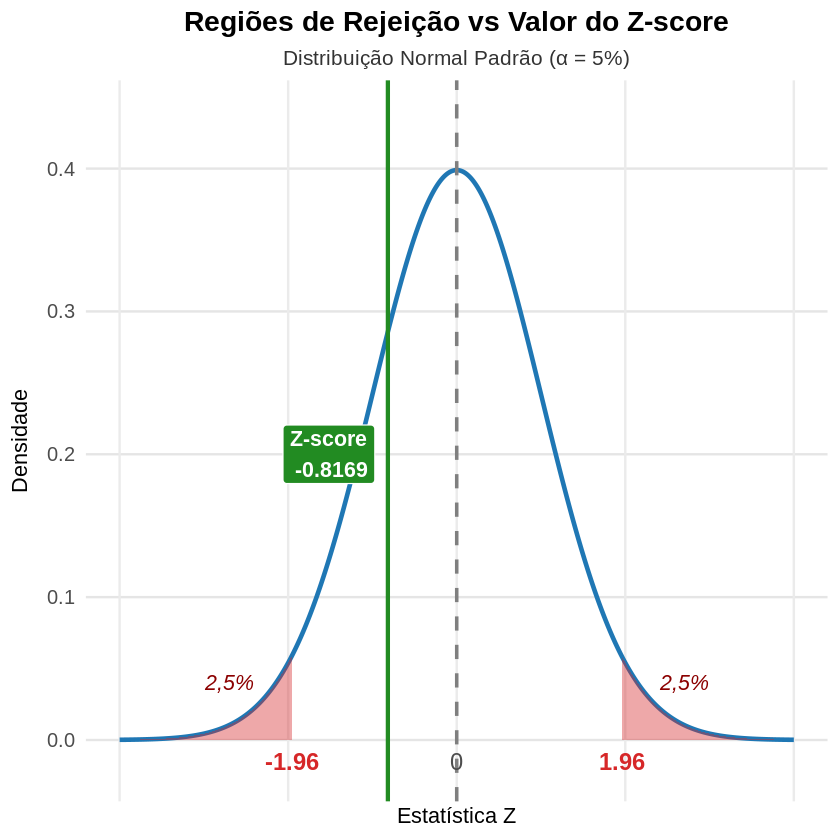

In [ ]:
library(ggplot2)

# 1. Parâmetros da Distribuição Normal Padrão (Teste Z)
mu_z      <- 0
sd_z      <- 1
z_score   <- -0.8169  # Nosso valor calculado
z_critico <- 1.96     # Nível de confiança 95% (bicaudal)

# 2. Gerar dados para a curva normal
x_vals <- seq(-4, 4, length.out = 500)
dens   <- dnorm(x_vals, mean = mu_z, sd = sd_z)
df_curva <- data.frame(x = x_vals, y = dens)

# 3. Gerar dados para sombrear as áreas de rejeição (Caudas de 2,5%)
x_esq <- seq(-4, -z_critico, length.out = 100)
y_esq <- dnorm(x_esq, mean = mu_z, sd = sd_z)
df_esq <- data.frame(x = x_esq, y = y_esq)

x_dir <- seq(z_critico, 4, length.out = 100)
y_dir <- dnorm(x_dir, mean = mu_z, sd = sd_z)
df_dir <- data.frame(x = x_dir, y = y_dir)

# 4. Construindo o gráfico com ggplot2
ggplot() +

  # Curva normal padrão
  geom_line(data = df_curva, aes(x = x, y = y), color = "#1f77b4", linewidth = 1.3) +

  # Áreas de rejeição (Caudas em vermelho claro)
  geom_area(data = df_esq, aes(x = x, y = y), fill = "#d62728", alpha = 0.4) +
  geom_area(data = df_dir, aes(x = x, y = y), fill = "#d62728", alpha = 0.4) +

  # Linha central indicando a média (Z = 0)
  geom_vline(xintercept = 0, color = "gray50", linetype = "dashed", linewidth = 1) +

  # Linha marcando nosso Z-Score calculado (em verde)
  geom_vline(xintercept = z_score, color = "forestgreen", linewidth = 1.2) +

  # Textos com os valores baseados no esboço manual
  annotate("text", x = 0, y = -0.015, label = "0", size = 5, color = "gray30") +
  annotate("text", x = -z_critico, y = -0.015, label = "-1.96", size = 5, color = "#d62728", fontface = "bold") +
  annotate("text", x = z_critico, y = -0.015, label = "1.96", size = 5, color = "#d62728", fontface = "bold") +

  # Textos das probabilidades (2,5%)
  annotate("text", x = -2.7, y = 0.04, label = "2,5%", size = 4.5, color = "darkred", fontface = "italic") +
  annotate("text", x = 2.7, y = 0.04, label = "2,5%", size = 4.5, color = "darkred", fontface = "italic") +

  # Caixa de texto marcando o Z-score
  annotate("label", x = z_score - 0.7, y = 0.2,
           label = paste("Z-score\n", z_score),
           color = "white", fill = "forestgreen", fontface = "bold", size = 4.5) +

  # Rótulos e Títulos
  labs(title = "Regiões de Rejeição vs Valor do Z-score",
       subtitle = "Distribuição Normal Padrão (\u03b1 = 5%)",
       x = "Estatística Z",
       y = "Densidade") +

  # Expande um pouco a margem inferior de Y para caberem as anotações do eixo
  coord_cartesian(ylim = c(-0.02, max(dens) * 1.1)) +

  # Tema limpo (igual ao da Etapa 2)
  theme_minimal(base_size = 15) +
  theme(
    plot.title = element_text(face = "bold", size = 17, hjust = 0.5),
    plot.subtitle = element_text(size = 12.5, hjust = 0.5, color = "gray20"),
    axis.title = element_text(size = 13),
    panel.grid.minor = element_blank(),
    panel.grid.major.y = element_line(color = "gray90"),
    axis.text.x = element_blank() # Oculta os números padrões do eixo para dar destaque as nossas anotações (0, 1.96)
  )

In [ ]:
# 1. Defina o seu z-score calculado
z_score <- -0.8166401

# 2. Use a função pnorm() passando o z_score no parâmetro 'q'
# Em um z-score, a média (mean) é sempre 0 e o desvio padrão (sd) é 1.
probabilidade_cauda <- pnorm(q = z_score, mean = 0, sd = 1)

# 3. Multiplique por 2 para obter o p-valor do teste bicaudal
p_valor <- 2 * probabilidade_cauda

# Exibir o resultado
cat("p-valor:",p_valor)

#REGRA BASEADA em α e P-VALOR
#P-VALOR < α ⇒ REJEITA H₀
#P-VALOR > α ⇒ ACEITA H₀ (não rejeita)

aceita_h0 <- p_valor > 0.05

cat("\nAceita Ho:",aceita_h0)

p-valor: 0.4141341
Aceita Ho: TRUE

### Etapa 4: Diagnóstico de Outliers e Impacto nas Estimativas

Nesta última etapa, nosso objetivo é realizar o diagnóstico de *outliers* (valores atípicos ou discrepantes) na nossa amostra. No contexto do monitoramento astronômico, esses valores extremos geralmente representam falhas instrumentais pontuais ou interferências atmosféricas severas captadas pelo telescópio, e não uma variação real no brilho da estrela.

**Metodologia de Identificação:**
Para detectar essas anomalias, utilizaremos o método gráfico do **Boxplot** (Diagrama de Caixa), aliado à regra matemática da **Amplitude Interquartílica (IQR)**. Por essa regra clássica da estatística descritiva, varremos todo o conjunto de dados e consideramos como *outlier* qualquer medição que caia fora das "cercas" de tolerância:
*   **Limite Inferior:** $Q1 - 1.5 \times IQR$
*   **Limite Superior:** $Q3 + 1.5 \times IQR$

**Quantificando o Impacto:**
Conforme a teoria estatística, valores extremos distorcem fortemente a Média Aritmética e inflam as medidas de dispersão (como o desvio padrão), enquanto a **Mediana atua como uma estatística robusta**, pois depende apenas da posição central dos dados e não é afetada por esses desvios.

Para cumprir o requisito final do projeto, iremos identificar e isolar os *outliers* e, em seguida, recalcular os sumários estatísticos com a base de dados "limpa". Isso nos permitirá comprovar matematicamente o quanto essas falhas do telescópio estavam inflando artificialmente a dispersão (ruído) da nossa estimativa original.


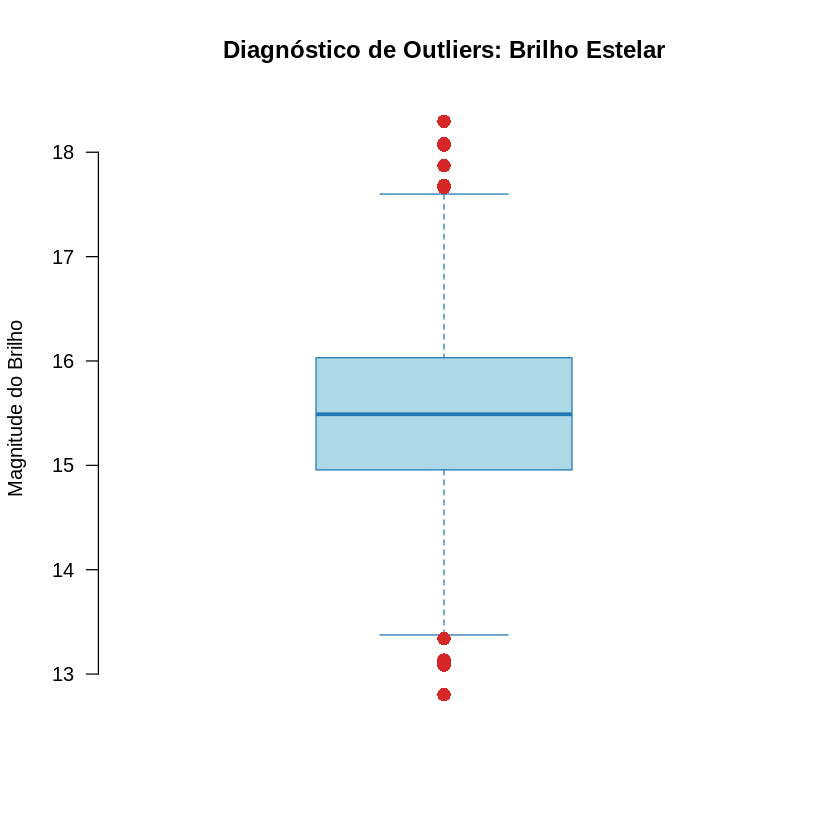

In [ ]:
# Ajuste de margens do gráfico para um visual mais espaçado e limpo
#par(mar = c(3, 5, 4, 2))

# Gerando o gráfico com a função nativa boxplot(), mas com estilo aprimorado
boxplot(brilho_estelar,
        main = "Diagnóstico de Outliers: Brilho Estelar",
        ylab = "Magnitude do Brilho",
        col = "lightblue",           # Cor de preenchimento da caixa sugerida por você
        border = "#1f77b4",          # Cor da linha da caixa (o mesmo azul escuro elegante dos gráficos anteriores)
        outcol = "#d62728",          # Destaca os outliers (valores extremos) com a cor vermelha
        outpch = 16,                 # Formato do outlier (16 = círculo preenchido)
        outcex = 1.5,                # Aumenta levemente o tamanho do ponto do outlier para saltar aos olhos
        las = 1,                     # Mantém os valores numéricos do eixo Y na horizontal para facilitar a leitura
        frame.plot = FALSE)          # Remove a moldura preta rígida ao redor do gráfico (estilo minimalista)


IQR = 1.071573
limite_inf = 13.35227
limite_sup = 17.63856
Outlier =  13.10553
Outlier =  17.66151
Outlier =  13.34006
Outlier =  17.87269
Outlier =  18.08326
Outlier =  13.08565
Outlier =  18.06896
Outlier =  17.68176
Outlier =  13.13298
Outlier =  12.80261
Outlier =  18.29624

mediana com outline: 15.48949
mediana sem outline: 15.48947

média com outline: 15.47934
média sem outline: 15.47645

sd com outline: 0.802017
sd sem outline: 0.7643407

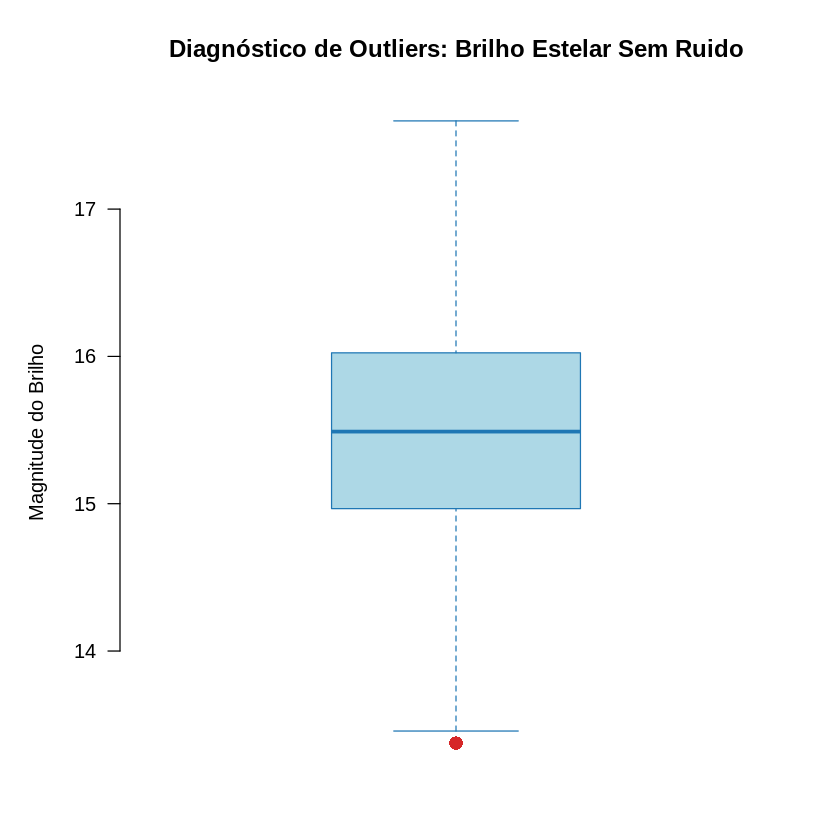

In [ ]:
q1 <-quantile(brilho_estelar,c(0.25))
q2 <-quantile(brilho_estelar,c(0.50))
q3 <-quantile(brilho_estelar,c(0.75))

iqr<- q3-q1  #DISTINCIA INTERQUARTILICA (Q3-Q1)

#paste(c(q1,q2,q3))

varli<- q1-1.5*(iqr) # LIMITE INFERIOR
varls<- q3+1.5*(iqr) # LIMITE SUPERIOR

cat("\nIQR =",iqr)
cat("\nlimite_inf =",varli)
cat("\nlimite_sup =",varls)

#boxplot(brilho_estelar,main="brilho_estelar",xlab="Box-plot var",ylab="var")

#outlx = varx>varxls
outl = brilho_estelar>varls | brilho_estelar<varli   # Vari?vel L?gica
#outl

#============================
# IMPRESS?O DOS OUTLIERS-VARX
#============================
for (i in 1:n){
  if(outl[i]=="TRUE"){
      cat("\nOutlier = ",brilho_estelar[i])}
}

# Identifica os valores dos outliers
valores_outliers <- boxplot.stats(brilho_estelar)$out

# Cria um novo vetor mantendo apenas os dados que NÃO estão na lista de outliers
brilho_limpo <- brilho_estelar[!brilho_estelar %in% valores_outliers]

sd_sem_outliers <- sd(brilho_limpo)

cat("\n\nmediana com outline:",median(brilho_estelar))
cat("\nmediana sem outline:",median(brilho_limpo))

cat("\n\nmédia com outline:",mean(brilho_estelar))
cat("\nmédia sem outline:",mean(brilho_limpo))

cat("\n\nsd com outline:",sd(brilho_estelar))
cat("\nsd sem outline:",sd_sem_outliers)

# Ajuste de margens do gráfico para um visual mais espaçado e limpo
par(mar = c(3, 5, 4, 2))

# Gerando o gráfico com a função nativa boxplot(), mas com estilo aprimorado
boxplot(brilho_limpo,
        main = "Diagnóstico de Outliers: Brilho Estelar Sem Ruido",
        ylab = "Magnitude do Brilho",
        col = "lightblue",           # Cor de preenchimento da caixa sugerida por você
        border = "#1f77b4",          # Cor da linha da caixa (o mesmo azul escuro elegante dos gráficos anteriores)
        outcol = "#d62728",          # Destaca os outliers (valores extremos) com a cor vermelha
        outpch = 16,                 # Formato do outlier (16 = círculo preenchido)
        outcex = 1.5,                # Aumenta levemente o tamanho do ponto do outlier para saltar aos olhos
        las = 1,                     # Mantém os valores numéricos do eixo Y na horizontal para facilitar a leitura
        frame.plot = FALSE)          # Remove a moldura preta rígida ao redor do gráfico (estilo minimalista)
